# 07. Popularity baseline recommender

This notebook implements the simplest recommendation benchmark in the project: a global popularity baseline.

The model recommends the most popular recipes learned from the training split only.  
It is used as the first comparison point before collaborative filtering and SVD.

Main tasks in this notebook:

- load chronological implicit train, validation, and test splits
- compute global item popularity from training data only
- generate top-N recommendations
- exclude items already seen by each user in training
- evaluate ranking quality on validation and test splits
- analyse popularity concentration and catalogue coverage
- save tables, figures, recommendation outputs, and a compact log

In [30]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Set project paths

In [31]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    ensure_directories,
)

In [32]:
MODEL_NAME = "popularity"

TOP_K_VALUES = [5, 10, 20]
EXPORT_TOP_N = 10

TABLES_SUBDIR = TABLES_DIR / MODEL_NAME
FIGURES_SUBDIR = FIGURES_DIR / MODEL_NAME
LOGS_SUBDIR = LOGS_DIR / MODEL_NAME

ensure_directories()
TABLES_SUBDIR.mkdir(parents=True, exist_ok=True)
FIGURES_SUBDIR.mkdir(parents=True, exist_ok=True)
LOGS_SUBDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split directory:", SPLITS_DIR)
print("Tables output:", TABLES_SUBDIR)
print("Figures output:", FIGURES_SUBDIR)
print("Logs output:", LOGS_SUBDIR)

Project root: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project
Split directory: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits
Tables output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity
Figures output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\popularity
Logs output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\popularity


## 2. Load implicit chronological splits

The popularity baseline is fitted on the implicit interaction split, because the implicit dataset retains all observed user–recipe interactions and is the most suitable source for Top-N recommendation experiments.

In [33]:
train_path = SPLITS_DIR / "implicit_train.parquet"
valid_path = SPLITS_DIR / "implicit_valid.parquet"
test_path = SPLITS_DIR / "implicit_test.parquet"

for path in [train_path, valid_path, test_path]:
    print(path, "exists:", path.exists())

implicit_train = pd.read_parquet(train_path).copy()
implicit_valid = pd.read_parquet(valid_path).copy()
implicit_test = pd.read_parquet(test_path).copy()

E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_train.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_valid.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_test.parquet exists: True


In [34]:
print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

print("\nTrain columns:")
print(list(implicit_train.columns))

print("\nValid columns:")
print(list(implicit_valid.columns))

print("\nTest columns:")
print(list(implicit_test.columns))

Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)

Train columns:
['user_id', 'recipe_id', 'date', 'rating', 'review_exists', 'is_unrated_observation', 'implicit_feedback', 'user_idx', 'item_idx']

Valid columns:
['user_id', 'recipe_id', 'date', 'rating', 'review_exists', 'is_unrated_observation', 'implicit_feedback', 'user_idx', 'item_idx']

Test columns:
['user_id', 'recipe_id', 'date', 'rating', 'review_exists', 'is_unrated_observation', 'implicit_feedback', 'user_idx', 'item_idx']


In [35]:
required_cols = ["user_id", "recipe_id", "date", "implicit_feedback"]

for name, df in {
    "implicit_train": implicit_train,
    "implicit_valid": implicit_valid,
    "implicit_test": implicit_test,
}.items():
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

print("All required columns are present.")

All required columns are present.


In [36]:
for df in [implicit_train, implicit_valid, implicit_test]:
    df["date"] = pd.to_datetime(df["date"])

print("Train date range:", implicit_train["date"].min(), "to", implicit_train["date"].max())
print("Valid date range:", implicit_valid["date"].min(), "to", implicit_valid["date"].max())
print("Test date range:", implicit_test["date"].min(), "to", implicit_test["date"].max())

Train date range: 2000-01-25 00:00:00 to 2010-06-17 00:00:00
Valid date range: 2010-06-17 00:00:00 to 2012-12-28 00:00:00
Test date range: 2012-12-28 00:00:00 to 2018-12-20 00:00:00


## 3. Quick split summary

This is a simple check that the split files are loaded correctly and still align with the chronological pipeline.

In [37]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": int(len(implicit_train)),
        "users": int(implicit_train["user_id"].nunique()),
        "recipes": int(implicit_train["recipe_id"].nunique()),
        "min_date": implicit_train["date"].min(),
        "max_date": implicit_train["date"].max(),
    },
    {
        "split": "valid",
        "rows": int(len(implicit_valid)),
        "users": int(implicit_valid["user_id"].nunique()),
        "recipes": int(implicit_valid["recipe_id"].nunique()),
        "min_date": implicit_valid["date"].min(),
        "max_date": implicit_valid["date"].max(),
    },
    {
        "split": "test",
        "rows": int(len(implicit_test)),
        "users": int(implicit_test["user_id"].nunique()),
        "recipes": int(implicit_test["recipe_id"].nunique()),
        "min_date": implicit_test["date"].min(),
        "max_date": implicit_test["date"].max(),
    },
])

split_summary

,split,rows,users,recipes,min_date,max_date
0,train,792656,106304,186564,2000-01-25,2010-06-17
1,valid,169855,46047,78532,2010-06-17,2012-12-28
2,test,169856,97133,61095,2012-12-28,2018-12-20


## 4. Build the global popularity table

Popularity is learned from the training split only.

The main signal is interaction count.  
Additional fields such as user count and mean rating are kept for interpretation and tie-breaking.

In [38]:
item_popularity = (
    implicit_train.groupby("recipe_id", as_index=False)
    .agg(
        interaction_count=("implicit_feedback", "sum"),
        user_count=("user_id", "nunique"),
        mean_rating=("rating", "mean"),
        first_seen_date=("date", "min"),
        last_seen_date=("date", "max"),
    )
    .sort_values(
        by=["interaction_count", "user_count", "mean_rating", "recipe_id"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

item_popularity["popularity_rank"] = np.arange(1, len(item_popularity) + 1)
item_popularity["popularity_score"] = (
    item_popularity["interaction_count"] / item_popularity["interaction_count"].max()
)

item_popularity.head(10)

,recipe_id,interaction_count,user_count,mean_rating,first_seen_date,last_seen_date,popularity_rank,popularity_score
0,27208,1141,1141,4.422436,2002-05-04,2010-06-10,1,1.000000
1,89204,1054,1054,4.428843,2004-04-20,2010-06-10,2,0.923751
2,39087,923,923,4.711809,2002-10-06,2010-06-13,3,0.808940
3,32204,911,911,4.656422,2002-06-24,2010-06-16,4,0.798422
4,22782,799,799,4.602003,2002-03-27,2010-06-16,5,0.700263
5,67256,754,754,4.559682,2003-08-16,2010-06-16,6,0.660824
6,54257,725,725,4.506207,2003-04-06,2010-06-15,7,0.635408
7,25885,688,688,4.513081,2002-05-27,2010-06-13,8,0.602980
8,68955,687,687,4.534207,2003-08-17,2010-06-07,9,0.602103
9,28148,672,672,4.748512,2002-05-16,2010-05-29,10,0.588957


In [39]:
print("Number of ranked items:", len(item_popularity))
print("Top recipe interaction count:", int(item_popularity["interaction_count"].max()))
print("Median recipe interaction count:", float(item_popularity["interaction_count"].median()))
print("Recipes with only 1 interaction in train:", int((item_popularity["interaction_count"] == 1).sum()))

Number of ranked items: 186564
Top recipe interaction count: 1141
Median recipe interaction count: 2.0
Recipes with only 1 interaction in train: 78178


## 5. Analyse the long-tail popularity structure

This helps show how concentrated the training interactions are.

In [40]:
popularity_curve = item_popularity.copy()
popularity_curve["interaction_share"] = (
    popularity_curve["interaction_count"] / popularity_curve["interaction_count"].sum()
)
popularity_curve["cumulative_interaction_share"] = popularity_curve["interaction_share"].cumsum()
popularity_curve["cumulative_item_share"] = (
    np.arange(1, len(popularity_curve) + 1) / len(popularity_curve)
)

popularity_curve.head()

,recipe_id,interaction_count,user_count,mean_rating,first_seen_date,last_seen_date,popularity_rank,popularity_score,interaction_share,cumulative_interaction_share,cumulative_item_share
0,27208,1141,1141,4.422436,2002-05-04,2010-06-10,1,1.000000,0.001439,0.001439,0.000005
1,89204,1054,1054,4.428843,2004-04-20,2010-06-10,2,0.923751,0.001330,0.002769,0.000011
2,39087,923,923,4.711809,2002-10-06,2010-06-13,3,0.808940,0.001164,0.003934,0.000016
3,32204,911,911,4.656422,2002-06-24,2010-06-16,4,0.798422,0.001149,0.005083,0.000021
4,22782,799,799,4.602003,2002-03-27,2010-06-16,5,0.700263,0.001008,0.006091,0.000027


In [41]:
checkpoints = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]

distribution_rows = []
for cutoff in checkpoints:
    n_items = max(1, int(math.ceil(len(popularity_curve) * cutoff)))
    subset = popularity_curve.iloc[:n_items]
    distribution_rows.append({
        "top_item_share": cutoff,
        "top_item_count": int(n_items),
        "interaction_share_captured": float(subset["interaction_share"].sum()),
    })

popularity_distribution_summary = pd.DataFrame(distribution_rows)
popularity_distribution_summary

,top_item_share,top_item_count,interaction_share_captured
0,0.01,1866,0.208990
1,0.05,9329,0.402323
2,0.10,18657,0.518983
3,0.20,37313,0.660461
4,0.50,93282,0.863262
5,1.00,186564,1.000000


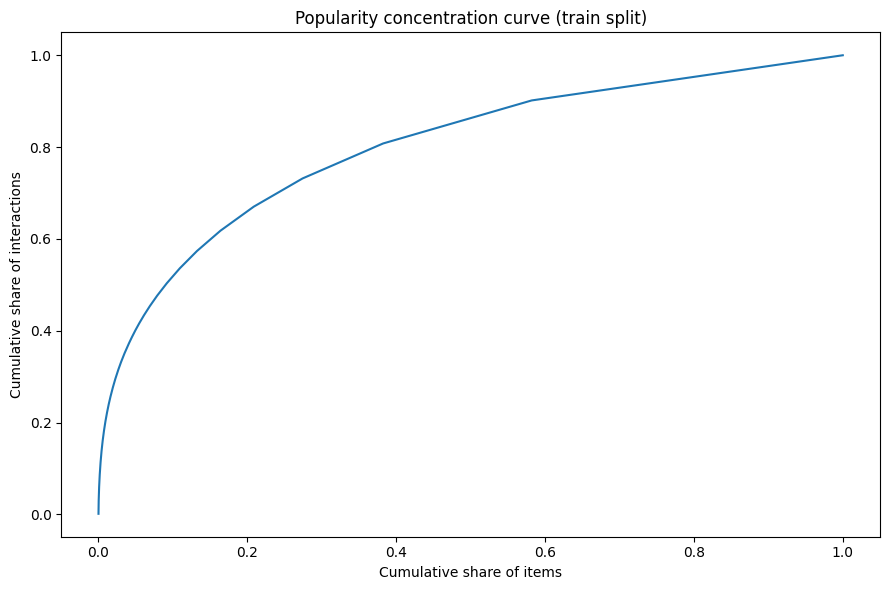

In [42]:
plt.figure(figsize=(9, 6))
plt.plot(
    popularity_curve["cumulative_item_share"],
    popularity_curve["cumulative_interaction_share"],
)
plt.xlabel("Cumulative share of items")
plt.ylabel("Cumulative share of interactions")
plt.title("Popularity concentration curve (train split)")
plt.tight_layout()
plt.show()

## 6. Build user training history

Seen items from the training split will be excluded from each user's recommendation list.

In [43]:
user_seen_train = (
    implicit_train.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

print("Users with train history:", len(user_seen_train))

Users with train history: 106304


## 7. Build holdout ground-truth sets

For Top-N evaluation, duplicate user–item interactions inside a holdout split are collapsed into a set.

In [44]:
valid_truth = (
    implicit_valid.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

test_truth = (
    implicit_test.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

print("Validation users with holdout items:", len(valid_truth))
print("Test users with holdout items:", len(test_truth))

Validation users with holdout items: 46047
Test users with holdout items: 97133


## 8. Define recommendation and evaluation helpers

In [45]:
ranked_recipe_ids = item_popularity["recipe_id"].to_numpy()


def get_top_n_popular_unseen(user_id: int, top_n: int = 10) -> list[int]:
    seen = user_seen_train.get(user_id, set())
    recs = []

    for recipe_id in ranked_recipe_ids:
        if recipe_id not in seen:
            recs.append(int(recipe_id))
        if len(recs) == top_n:
            break

    return recs


def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k <= 0:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    return float(any(item in relevant for item in recommended[:k]))


def dcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    score = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / math.log2(rank + 1)
    return score


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0

    ideal_hits = min(len(relevant), k)
    ideal_dcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    if ideal_dcg == 0:
        return 0.0

    return dcg_at_k(recommended, relevant, k) / ideal_dcg

## 9. Define novelty from train popularity

Novelty is measured using self-information.  
Higher novelty means the recommended items are less globally popular.

In [46]:
item_probability = (
    item_popularity.set_index("recipe_id")["interaction_count"]
    / item_popularity["interaction_count"].sum()
)

item_self_information = {
    int(recipe_id): float(-math.log2(prob))
    for recipe_id, prob in item_probability.items()
    if prob > 0
}


def novelty_at_k(recommended: list[int], k: int) -> float:
    items = recommended[:k]
    if not items:
        return 0.0
    return float(np.mean([item_self_information.get(item, 0.0) for item in items]))

## 10. Evaluate the validation split

In [47]:
valid_user_rows = []
valid_recommended_by_k = {k: [] for k in TOP_K_VALUES}

for user_id, relevant_items in valid_truth.items():
    recs = get_top_n_popular_unseen(user_id, top_n=max(TOP_K_VALUES + [EXPORT_TOP_N]))

    row = {
        "split": "valid",
        "user_id": int(user_id),
        "holdout_item_count": int(len(relevant_items)),
        "recommended_recipe_ids": recs[:EXPORT_TOP_N],
    }

    for k in TOP_K_VALUES:
        row[f"precision_at_{k}"] = precision_at_k(recs, relevant_items, k)
        row[f"recall_at_{k}"] = recall_at_k(recs, relevant_items, k)
        row[f"hit_rate_at_{k}"] = hit_rate_at_k(recs, relevant_items, k)
        row[f"ndcg_at_{k}"] = ndcg_at_k(recs, relevant_items, k)
        row[f"novelty_at_{k}"] = novelty_at_k(recs, k)

        valid_recommended_by_k[k].extend(recs[:k])

    valid_user_rows.append(row)

valid_user_metrics = pd.DataFrame(valid_user_rows)
valid_user_metrics.head()

,split,user_id,holdout_item_count,recommended_recipe_ids,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,novelty_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,novelty_at_10,precision_at_20,recall_at_20,hit_rate_at_20,ndcg_at_20,novelty_at_20
0,valid,1535,42,"[89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148, 69173]",0.0,0.0,0.0,0.0,9.811610,0.0,0.0,0.0,0.0,9.992664,0.0,0.0,0.0,0.0,10.328206
1,valid,1634,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]",0.0,0.0,0.0,0.0,9.692078,0.0,0.0,0.0,0.0,9.913906,0.0,0.0,0.0,0.0,10.242716
2,valid,1676,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]",0.0,0.0,0.0,0.0,9.692078,0.0,0.0,0.0,0.0,9.913906,0.0,0.0,0.0,0.0,10.242716
3,valid,1792,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 28148, 69173]",0.0,0.0,0.0,0.0,9.692078,0.0,0.0,0.0,0.0,9.919472,0.0,0.0,0.0,0.0,10.272280
4,valid,1891,1,"[27208, 89204, 39087, 32204, 67256, 54257, 25885, 68955, 28148, 69173]",0.0,0.0,0.0,0.0,9.708804,0.0,0.0,0.0,0.0,9.941260,0.0,0.0,0.0,0.0,10.283174


In [48]:
valid_metric_rows = []

catalog_size = int(item_popularity["recipe_id"].nunique())

for k in TOP_K_VALUES:
    unique_recommended = len(set(valid_recommended_by_k[k]))

    valid_metric_rows.append({
        "split": "valid",
        "k": k,
        "users_evaluated": int(valid_user_metrics["user_id"].nunique()),
        "precision_at_k": float(valid_user_metrics[f"precision_at_{k}"].mean()),
        "recall_at_k": float(valid_user_metrics[f"recall_at_{k}"].mean()),
        "hit_rate_at_k": float(valid_user_metrics[f"hit_rate_at_{k}"].mean()),
        "ndcg_at_k": float(valid_user_metrics[f"ndcg_at_{k}"].mean()),
        "novelty_at_k": float(valid_user_metrics[f"novelty_at_{k}"].mean()),
        "catalog_coverage_at_k": float(unique_recommended / catalog_size),
        "recommendation_count": int(len(valid_recommended_by_k[k])),
    })

valid_metrics = pd.DataFrame(valid_metric_rows)
valid_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,46047,0.005564,0.013154,0.026104,0.010583,9.695873,0.000123,230235
1,valid,10,46047,0.004504,0.021060,0.041154,0.013137,9.917653,0.000220,460470
2,valid,20,46047,0.003709,0.033058,0.063718,0.016452,10.247692,0.000343,920940


## 11. Evaluate the test split

In [49]:
test_user_rows = []
test_recommended_by_k = {k: [] for k in TOP_K_VALUES}

for user_id, relevant_items in test_truth.items():
    recs = get_top_n_popular_unseen(user_id, top_n=max(TOP_K_VALUES + [EXPORT_TOP_N]))

    row = {
        "split": "test",
        "user_id": int(user_id),
        "holdout_item_count": int(len(relevant_items)),
        "recommended_recipe_ids": recs[:EXPORT_TOP_N],
    }

    for k in TOP_K_VALUES:
        row[f"precision_at_{k}"] = precision_at_k(recs, relevant_items, k)
        row[f"recall_at_{k}"] = recall_at_k(recs, relevant_items, k)
        row[f"hit_rate_at_{k}"] = hit_rate_at_k(recs, relevant_items, k)
        row[f"ndcg_at_{k}"] = ndcg_at_k(recs, relevant_items, k)
        row[f"novelty_at_{k}"] = novelty_at_k(recs, k)

        test_recommended_by_k[k].extend(recs[:k])

    test_user_rows.append(row)

test_user_metrics = pd.DataFrame(test_user_rows)
test_user_metrics.head()

,split,user_id,holdout_item_count,recommended_recipe_ids,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,novelty_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,novelty_at_10,precision_at_20,recall_at_20,hit_rate_at_20,ndcg_at_20,novelty_at_20
0,test,1535,84,"[89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148, 69173]",0.2,0.011905,1.0,0.213986,9.811610,0.1,0.011905,1.0,0.138862,9.992664,0.05,0.011905,1.0,0.089617,10.328206
1,test,1581,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]",0.0,0.000000,0.0,0.000000,9.692078,0.0,0.000000,0.0,0.000000,9.913906,0.00,0.000000,0.0,0.000000,10.242716
2,test,1676,3,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]",0.0,0.000000,0.0,0.000000,9.692078,0.0,0.000000,0.0,0.000000,9.913906,0.00,0.000000,0.0,0.000000,10.242716
3,test,2378,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]",0.0,0.000000,0.0,0.000000,9.692078,0.0,0.000000,0.0,0.000000,9.913906,0.00,0.000000,0.0,0.000000,10.242716
4,test,2586,3,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 69173]",0.0,0.000000,0.0,0.000000,9.692078,0.0,0.000000,0.0,0.000000,9.916287,0.00,0.000000,0.0,0.000000,10.270687


In [50]:
test_metric_rows = []

for k in TOP_K_VALUES:
    unique_recommended = len(set(test_recommended_by_k[k]))

    test_metric_rows.append({
        "split": "test",
        "k": k,
        "users_evaluated": int(test_user_metrics["user_id"].nunique()),
        "precision_at_k": float(test_user_metrics[f"precision_at_{k}"].mean()),
        "recall_at_k": float(test_user_metrics[f"recall_at_{k}"].mean()),
        "hit_rate_at_k": float(test_user_metrics[f"hit_rate_at_{k}"].mean()),
        "ndcg_at_k": float(test_user_metrics[f"ndcg_at_{k}"].mean()),
        "novelty_at_k": float(test_user_metrics[f"novelty_at_{k}"].mean()),
        "catalog_coverage_at_k": float(unique_recommended / catalog_size),
        "recommendation_count": int(len(test_recommended_by_k[k])),
    })

test_metrics = pd.DataFrame(test_metric_rows)
test_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,test,5,97133,0.002131,0.007190,0.010347,0.004591,9.693116,0.000118,485665
1,test,10,97133,0.002015,0.013935,0.019324,0.006928,9.914947,0.000204,971330
2,test,20,97133,0.001503,0.019284,0.027704,0.008400,10.244072,0.000343,1942660


## 12. Combine evaluation summaries

In [51]:
popularity_metrics = pd.concat([valid_metrics, test_metrics], ignore_index=True)
popularity_metrics

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,46047,0.005564,0.013154,0.026104,0.010583,9.695873,0.000123,230235
1,valid,10,46047,0.004504,0.021060,0.041154,0.013137,9.917653,0.000220,460470
2,valid,20,46047,0.003709,0.033058,0.063718,0.016452,10.247692,0.000343,920940
3,test,5,97133,0.002131,0.007190,0.010347,0.004591,9.693116,0.000118,485665
4,test,10,97133,0.002015,0.013935,0.019324,0.006928,9.914947,0.000204,971330
5,test,20,97133,0.001503,0.019284,0.027704,0.008400,10.244072,0.000343,1942660


## 13. Build recommendation export tables

A wide version is kept for quick inspection, and a long version is easier for later analysis or dashboard use.

In [52]:
valid_recommendations_wide = valid_user_metrics[
    ["split", "user_id", "holdout_item_count", "recommended_recipe_ids"]
].copy()

test_recommendations_wide = test_user_metrics[
    ["split", "user_id", "holdout_item_count", "recommended_recipe_ids"]
].copy()

valid_recommendations_wide.head()

,split,user_id,holdout_item_count,recommended_recipe_ids
0,valid,1535,42,"[89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148, 69173]"
1,valid,1634,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]"
2,valid,1676,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 68955, 28148]"
3,valid,1792,1,"[27208, 89204, 39087, 32204, 22782, 67256, 54257, 25885, 28148, 69173]"
4,valid,1891,1,"[27208, 89204, 39087, 32204, 67256, 54257, 25885, 68955, 28148, 69173]"


In [53]:
rank_lookup = item_popularity.set_index("recipe_id")[
    ["popularity_rank", "interaction_count", "popularity_score"]
].to_dict("index")


def expand_recommendations_long(df_wide: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in df_wide.itertuples(index=False):
        for rec_rank, recipe_id in enumerate(row.recommended_recipe_ids, start=1):
            meta = rank_lookup.get(recipe_id, {})
            rows.append({
                "split": row.split,
                "user_id": int(row.user_id),
                "holdout_item_count": int(row.holdout_item_count),
                "recommendation_rank": rec_rank,
                "recipe_id": int(recipe_id),
                "global_popularity_rank": meta.get("popularity_rank"),
                "train_interaction_count": meta.get("interaction_count"),
                "popularity_score": meta.get("popularity_score"),
            })

    return pd.DataFrame(rows)


valid_recommendations_long = expand_recommendations_long(valid_recommendations_wide)
test_recommendations_long = expand_recommendations_long(test_recommendations_wide)

valid_recommendations_long.head(20)

,split,user_id,holdout_item_count,recommendation_rank,recipe_id,global_popularity_rank,train_interaction_count,popularity_score
0,valid,1535,42,1,89204,2,1054,0.923751
1,valid,1535,42,2,39087,3,923,0.808940
2,valid,1535,42,3,32204,4,911,0.798422
3,valid,1535,42,4,22782,5,799,0.700263
4,valid,1535,42,5,67256,6,754,0.660824
5,valid,1535,42,6,54257,7,725,0.635408
6,valid,1535,42,7,25885,8,688,0.602980
7,valid,1535,42,8,68955,9,687,0.602103
8,valid,1535,42,9,28148,10,672,0.588957
9,valid,1535,42,10,69173,11,661,0.579316


## 14. Create a compact run summary

In [54]:
run_summary = {
    "model": "popularity",
    "train_rows": int(len(implicit_train)),
    "valid_rows": int(len(implicit_valid)),
    "test_rows": int(len(implicit_test)),
    "train_users": int(implicit_train["user_id"].nunique()),
    "valid_users": int(implicit_valid["user_id"].nunique()),
    "test_users": int(implicit_test["user_id"].nunique()),
    "train_recipes": int(implicit_train["recipe_id"].nunique()),
    "valid_recipes": int(implicit_valid["recipe_id"].nunique()),
    "test_recipes": int(implicit_test["recipe_id"].nunique()),
    "top_k_values": TOP_K_VALUES,
    "ranked_recipe_count": int(len(item_popularity)),
    "most_popular_recipe_id": int(item_popularity.iloc[0]["recipe_id"]),
    "most_popular_interaction_count": int(item_popularity.iloc[0]["interaction_count"]),
    "metrics": popularity_metrics.to_dict(orient="records"),
}

run_summary

{'model': 'popularity',
 'train_rows': 792656,
 'valid_rows': 169855,
 'test_rows': 169856,
 'train_users': 106304,
 'valid_users': 46047,
 'test_users': 97133,
 'train_recipes': 186564,
 'valid_recipes': 78532,
 'test_recipes': 61095,
 'top_k_values': [5, 10, 20],
 'ranked_recipe_count': 186564,
 'most_popular_recipe_id': 27208,
 'most_popular_interaction_count': 1141,
 'metrics': [{'split': 'valid',
   'k': 5,
   'users_evaluated': 46047,
   'precision_at_k': 0.005563880383086847,
   'recall_at_k': 0.013154477401511157,
   'hit_rate_at_k': 0.02610376354594219,
   'ndcg_at_k': 0.010583426542650832,
   'novelty_at_k': 9.695873360600958,
   'catalog_coverage_at_k': 0.00012328209086426105,
   'recommendation_count': 230235},
  {'split': 'valid',
   'k': 10,
   'users_evaluated': 46047,
   'precision_at_k': 0.0045040936434512565,
   'recall_at_k': 0.02106008663783447,
   'hit_rate_at_k': 0.041153603926423005,
   'ndcg_at_k': 0.013137345204735038,
   'novelty_at_k': 9.917652713589183,
   '

## 15. Save output tables

In [55]:
item_popularity.to_csv(
    TABLES_SUBDIR / "07_item_popularity_table.csv",
    index=False,
)

split_summary.to_csv(
    TABLES_SUBDIR / "07_popularity_split_summary.csv",
    index=False,
)

popularity_distribution_summary.to_csv(
    TABLES_SUBDIR / "07_popularity_distribution_summary.csv",
    index=False,
)

valid_recommendations_wide.to_csv(
    TABLES_SUBDIR / "07_popularity_valid_recommendations_wide.csv",
    index=False,
)

test_recommendations_wide.to_csv(
    TABLES_SUBDIR / "07_popularity_test_recommendations_wide.csv",
    index=False,
)

valid_recommendations_long.to_csv(
    TABLES_SUBDIR / "07_popularity_valid_recommendations_long.csv",
    index=False,
)

test_recommendations_long.to_csv(
    TABLES_SUBDIR / "07_popularity_test_recommendations_long.csv",
    index=False,
)

popularity_metrics.to_csv(
    TABLES_SUBDIR / "07_popularity_metrics.csv",
    index=False,
)

print("Popularity tables saved to:", TABLES_SUBDIR)

Popularity tables saved to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity


## 16. Save figure

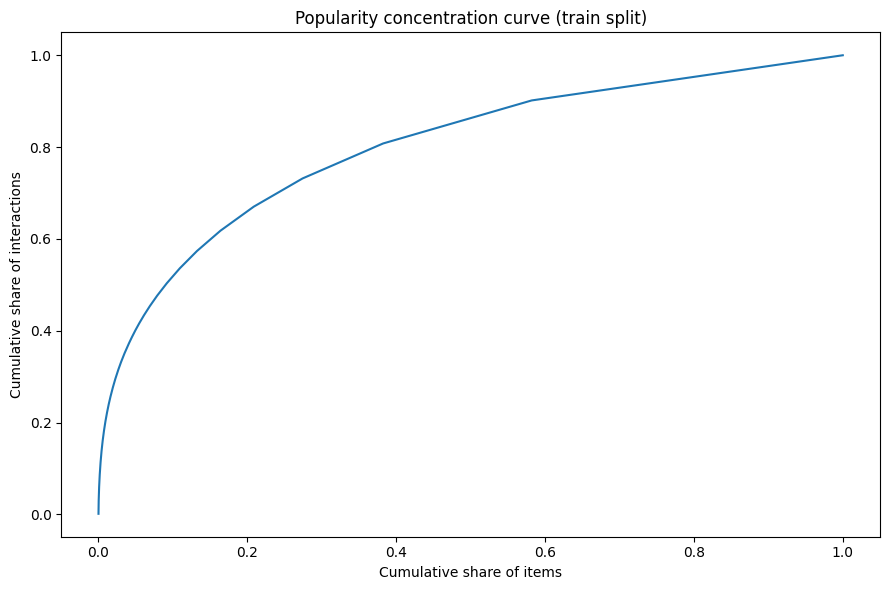

Saved figure to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\popularity\07_popularity_concentration_curve.png


In [56]:
figure_path = FIGURES_SUBDIR / "07_popularity_concentration_curve.png"

plt.figure(figsize=(9, 6))
plt.plot(
    popularity_curve["cumulative_item_share"],
    popularity_curve["cumulative_interaction_share"],
)
plt.xlabel("Cumulative share of items")
plt.ylabel("Cumulative share of interactions")
plt.title("Popularity concentration curve (train split)")
plt.tight_layout()
plt.savefig(figure_path, dpi=200)
plt.show()

print("Saved figure to:", figure_path)

## 17. Save compact JSON log

In [57]:
log_path = LOGS_SUBDIR / "07_popularity_log.json"

with open(log_path, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Saved log to:", log_path)

Saved log to: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\popularity\07_popularity_log.json


## 18. Final summary

This notebook implemented the popularity baseline recommender using the chronological implicit interaction splits.

Key design decisions in this phase:

- the implicit interaction split was used for Top-N recommendation
- item popularity was learned from training data only
- recommendation lists excluded items already seen by each user in training
- validation and test were evaluated with ranking metrics
- popularity concentration and catalogue coverage were measured
- outputs were saved for later comparison, reporting, and dashboard integration

These outputs are now ready for:

- collaborative filtering comparison
- SVD comparison
- unified evaluation tables
- dashboard recommendation demo

In [58]:
print("Saved outputs:")
print("-", TABLES_SUBDIR / "07_item_popularity_table.csv")
print("-", TABLES_SUBDIR / "07_popularity_split_summary.csv")
print("-", TABLES_SUBDIR / "07_popularity_distribution_summary.csv")
print("-", TABLES_SUBDIR / "07_popularity_valid_recommendations_wide.csv")
print("-", TABLES_SUBDIR / "07_popularity_test_recommendations_wide.csv")
print("-", TABLES_SUBDIR / "07_popularity_valid_recommendations_long.csv")
print("-", TABLES_SUBDIR / "07_popularity_test_recommendations_long.csv")
print("-", TABLES_SUBDIR / "07_popularity_metrics.csv")
print("-", FIGURES_SUBDIR / "07_popularity_concentration_curve.png")
print("-", LOGS_SUBDIR / "07_popularity_log.json")

print("\nMetrics summary:")
display(popularity_metrics)

Saved outputs:
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_item_popularity_table.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_split_summary.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_distribution_summary.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_valid_recommendations_wide.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_test_recommendations_wide.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_valid_recommendations_long.csv
- E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\popularity\07_popularity_test_recommendations_long.csv
- E:\UWE\Class Notes\Year 3\

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,46047,0.005564,0.013154,0.026104,0.010583,9.695873,0.000123,230235
1,valid,10,46047,0.004504,0.021060,0.041154,0.013137,9.917653,0.000220,460470
2,valid,20,46047,0.003709,0.033058,0.063718,0.016452,10.247692,0.000343,920940
3,test,5,97133,0.002131,0.007190,0.010347,0.004591,9.693116,0.000118,485665
4,test,10,97133,0.002015,0.013935,0.019324,0.006928,9.914947,0.000204,971330
5,test,20,97133,0.001503,0.019284,0.027704,0.008400,10.244072,0.000343,1942660
